# Testing UOT with multiple subsets
So far, we've been testing UOT with a random_state variable set to 42. Results for this subset were promising. However, to ensure this isn't random chance, we'll verify these results for multiple different random seeds.

## Imports

In [1]:
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import hic_ot_bulk_clr, import_cool_dir, fetch_region, get_cool_name, hic_mask_threshold

# Setting data directory
sc_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data'
save_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_uot_clustering/OT/RandomSubsets'
metadata_save = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_uot_clustering/OT/Metadata'

## Helper Functions

### Data Handling

In [2]:
def map_cell_types(data: pd.DataFrame, cell_type_map: pd.DataFrame):
    '''
        Transforms file name to file name comparisons in a pandas dataframe
        to a long format where each comparison has its own row, specifying inter
        or intra cell type of interest interactions.

        This function assusming formatting used in this notebook.

        Parameters
        ----------
        data : pd.DataFrame
            File name to file name dataframe of comparisons (SCC or OT).
        cell_type_map : pd.DataFrame
            Dataframe mapping file names to cell types.

        Returns
        -------
        data_long : pd.DataFrame
            A long format version of data with cell type information.
    '''

    # Mapping file to type
    type_lookup = cell_type_map.set_index("cell_name")["cell_type"]

    # Long format
    data_long = data.reset_index().rename(columns={"index": "row_file"})
    data_long = data_long.melt(id_vars="row_file",
                        var_name="col_file",
                        value_name="value")
    # Mapping celltypes
    data_long["row_cell_type"] = data_long["row_file"].map(type_lookup)
    data_long["col_cell_type"] = data_long["col_file"].map(type_lookup)

    # Inter and intra
    data_long["relationship"] = (
        data_long["row_cell_type"] == data_long["col_cell_type"]
        ).map({True: "intra", False: "inter"})

    return data_long

def generate_ot_data(res: int=1, thres: int=95, reg_m: float = 10, cell_count: int=20, seed: int=42):
    '''
        Generates the OT data needed for the approach taken here

        This function is very specific to this notebook.

        Parameters
        ----------
            Default = None, uses no distance scaling.
        res : int
            Resolution to bin the data to in Mb.
            Default = 1.
        thres : int
            Threshold to use for the data.
            Default = 95.
        reg_m : float
            Unbalanced parameter to use.
            Default = 10.
        cell_count : int
            The top number of cells to be used.
            Default = 20.
        seed : int
            Seed for subsetting
            Default = 42.

        Returns
        -------
        ot_results_long : pd.DataFrame
            Long format pandas dataframe with the desired results.
    '''
    ### Importing Data ###    
    # Metadata
    metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')
    sampled_files = (
        metadata.groupby('cell_type')
                .apply(lambda x: x.sample(
                    n=min(len(x), cell_count),
                    replace=False,
                    random_state=seed
                ))
                .reset_index(drop=True)
    )
    samples = list(sampled_files["cell_name"])

    # Importing coolers
    sample_clrs = import_cool_dir(sc_dir, include=samples)

    # OT
    ot_results = hic_ot_bulk_clr(sample_clrs, sample_clrs, chrom='chr1', res=res, thres=thres,
                                 thres_type='percentile', norm='max', unbalanced=reg_m)

    # Save OT results
    ot_results.to_csv(f'{save_dir}/unbalanced_reg_m={reg_m}_cluster_{res}mb_{thres}_{cell_count}_seed={seed}.csv')

    # Convert to long form
    ot_results_long = map_cell_types(ot_results, sampled_files)

    return ot_results_long

def load_ot_results_long(folder: str, res: int, thres: int, cell_count: int, seed: int, reg_m: float|None = None):
    '''
        Loads all csv files corresponding to OT results
        in the given folder.

        This function is very specific to this notebook.

        Parameters
        ----------
        folder : str
            Path to folder that is to be imported.
        res : int
            Resolution used for analysis.
        thres : int
            Threshold used for analysis.
        cell_count : int
            Number of cells used for analysis.
        seed : int
            Seed used to select data.
        reg_m : float
            Unbalanced parameter used.
            Default = None, looks for balanced data.
        
        Returns
        -------
        ot_df_long : pd.Dataframe
            Long form dataframe with combined data from all
            OT results.
    '''
    folder = Path(folder)
    
    # Storage dictonary
    ot_dfs = []

    # Regex patterns
    cc = re.escape(str(cell_count))
    
    if reg_m is None:
        pattern = re.compile(
            rf"^balanced_(.*?)_cluster_{res}mb_{thres}_{cell_count}_seed={seed}\.csv$"
        )
    else:
        pattern = re.compile(
            rf"^unbalanced_reg_m={reg_m}_cluster_{res}mb_{thres}_{cell_count}_seed={seed}\.csv$"
        )

    for file in folder.glob("*.csv"):
        name = file.name

        m = pattern.match(name)
        if m:
            df = pd.read_csv(file, index_col=0)
            ot_dfs.append(df)

    # Covert to long and concatenate
    metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')
    ot_dfs_long = []
    for df in ot_dfs:
        ot_dfs_long.append(map_cell_types(df, metadata))
    
    ot_df_long = pd.concat(ot_dfs_long)

    return ot_df_long

def add_mass_to_long_df(long_df: pd.DataFrame, total_mass: pd.DataFrame):
    '''
        Adds total mass to long format dataframe.
        Assumes total_mass to be formatted as generated in this notebook.

        Parameters
        ----------
        long_df : pd.DataFrame
            Long format dataframe with OT data.
        total_mass : pd.DataFrame
            Dataframe with file names and masses.
        
        Returns
        -------
        long_df_mass : pd.DataFrame
            Long format dataframe with added mass metadata columns
    '''
    # Making mass map
    mass_map = total_mass.copy()
    mass_map = mass_map.set_index('file_name')['total_mass']

    # Adding row and col masses
    long_df_mass = long_df.copy()
    long_df_mass['row_mass'] = long_df_mass['row_file'].map(mass_map)
    long_df_mass['col_mass'] = long_df_mass['col_file'].map(mass_map)

    # Adding additional metrics
    long_df_mass['mass_sum'] = long_df_mass["row_mass"] + long_df_mass['col_mass']
    long_df_mass['mass_diff'] = abs(long_df_mass["row_mass"] - long_df_mass['col_mass'])
    long_df_mass['log_value'] = np.log10(long_df_mass['value'])
    return long_df_mass

### Visualization

In [3]:
def distribution_plot(data: pd.DataFrame, ax, seed: int, kind: str="interintra"):
    '''
        Plots the distribution of the provided dataframe to
        the provided Axes object.

        Function is very specific to this notebook.

        Parameters
        ----------
        data : pd.DataFrame
            Data to be plotted.
        ax
            Axes object to plot to.
        seed : int
            Used seed.
        kind : str
            The kind of elements to emphasize.
            'interintra' for inter vs intra celltype.
            'common' for common elements between datasets based
            on the 'is_common' column.
            Default = 'interintra'.
    '''
    # Setting order
    order = ["inter", "intra"]

    if kind == 'interintra':
        # Stripplot
        sns.stripplot(
        data=data,
        x="relationship",
        y="value",
        order=order,
        hue="relationship",
        dodge=False,
        jitter=True,
        alpha=0.05,
        palette={
            "inter": "#1f77b4",
            "intra": "#ff7f0e"
        },
        ax=ax
        )

        # Violin plot
        sns.violinplot(
            data=data,
            x="relationship",
            y="value",
            order=order,
            inner=None,
            color="lightgray",
            cut=0,
            ax=ax
        )
    elif kind == 'common':
        # Stripplot
        sns.stripplot(
        data=data,
        y="value",
        hue="is_common",
        dodge=False,
        jitter=True,
        alpha=0.1,
        palette={
            False: "#1f77b4",
            True: "#ff0e0e"
        },
        ax=ax
        )

        # Violin plot
        sns.violinplot(
            data=data,
            y="value",
            inner=None,
            color="lightgray",
            cut=0,
            ax=ax
        )
    else:
        raise ValueError(f"Unsupported kind: {kind}")

    ax.set_ylim(bottom=0)
    ax.set_ylabel("OT Loss")
    ax.set_title(f"UOT for seed={seed}")
    return

def generate_clustermap(data: pd.DataFrame, reg_m: float, seed: int):
    '''
        Generates a clustermap between cell types for the data generated
        in this notebook.

        Function is specific to this notebook.

        Parameters
        ----------
        data : pd.DataFrame
            Long format dataframe with cell-to-cell comparisons.
        reg_m : float
            Used reg_m value.
        seed : int
            Used seed for data selection.
    '''
    # Calculating means per cell type
    mean_matrix = data.groupby(
        ['row_cell_type', 'col_cell_type']
    )["value"].mean()

    # Prepping for generating heatmap
    heatmap_data = mean_matrix.unstack()

    # Clustermap
    sns.clustermap(heatmap_data, annot=True, fmt='.1f', cmap='viridis')
    plt.suptitle(f"Unbalanced (reg_m={reg_m}, seed={seed})", fontweight='bold')
    plt.tight_layout()

    return

def generate_marginal_plot(long_df: pd.DataFrame, mass_df: pd.DataFrame, reg_m: float, seed: int, kind: str = 'diff'):
    '''
        Generates marginal plots for metadata in long_df_mass.

        Parameters
        ----------
        long_df : pd.DataFrame
            Long format dataframe with OT results.
        mass_df : pd.DataFrame
            Dataframe with file to mass mappings.
        reg_m : float
            reg_m value used for UOT.
        seed : int
            Seed used for data selection.
        kind : str
            Kind of comparison to plot.
            'sum' = mass sum to OT loss.
            'diff' = mass difference to OT loss.
            Default = 'diff'
    '''
    sns.set_theme(style="white")

    # Adding mass data
    long_df_mass = add_mass_to_long_df(long_df, mass_df)

    # Setting comparison
    if kind == 'sum':
        compare = 'mass_sum'
        axis_title = 'Mass Sum'
    elif kind == 'diff':
        compare = 'mass_diff'
        axis_title = 'Mass Difference'
    else:
        raise ValueError(f"Invalid kind: {kind}")

    # Initialize grid
    g = sns.JointGrid(
        data=long_df_mass,
        x=compare,
        y='log_value',
        height=6
    )

    # Joint: light scatter + contour KDE
    g.ax_joint.scatter(
        long_df_mass[compare],
        long_df_mass['log_value'],
        s=8,
        alpha=0.25
    )

    sns.kdeplot(
        data=long_df_mass,
        x=compare,
        y='log_value',
        ax=g.ax_joint,
        levels=10,
        bw_adjust=0.8,
        color='black'
    )

    # Marginals
    sns.kdeplot(
        data=long_df_mass,
        x=compare,
        ax=g.ax_marg_x,
        fill=True,
        bw_adjust=0.8
    )

    sns.kdeplot(
        data=long_df_mass,
        y='log_value',
        ax=g.ax_marg_y,
        fill=True,
        bw_adjust=0.8
    )

    # Axis labels
    g.set_axis_labels(axis_title, 'log(OT Loss)')

    # Title
    g.figure.suptitle(f'Marginal Plot OT Loss and {axis_title}, UOT (reg_m={reg_m}, seed={seed})', fontweight='bold')
    g.figure.tight_layout(rect=[0, 0, 1, 0.98])
    return

## Generating Data

In [5]:
### OT per seed, reg_m = 0.1 ###
seeds = [42, 15, 338, 872, 674]

    # Getting all cell types
metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')

for seed in seeds:
    generate_ot_data(1, 95, 0.1, 20, seed)

/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_93292/1975549697.py:78: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


KeyboardInterrupt: 

## Load data

In [6]:
### Loading data per seed, reg_m = 0.1 ###
seeds = [42, 15, 338, 872, 674]
reg_m01_data = {}

for seed in seeds:
    reg_m01_data[seed] = load_ot_results_long(save_dir, 1, 95, 20, seed, 0.1)

## Constructing Total Mass DF

In [7]:
### Importing Counts ###
    # Import cools
sc_cools = import_cool_dir(sc_dir)

    # Extract chr1 and name
sc_chr1s = []
sc_names = []
for clr in sc_cools:
    sc_chr1s.append(fetch_region(clr, 'chr1'))
    sc_names.append(get_cool_name(clr))
del sc_cools

In [8]:
### Extracting Masses Considered ###
total_masses = []

for chr1 in sc_chr1s:
    mass_list = hic_mask_threshold(chr1, 95, "percentile", "max")[0]
    total_masses.append(mass_list.sum())

In [9]:
### Making and Saving Dataframe ###
max_norm_mass= pd.DataFrame({
    'file_name' : sc_names,
    'total_mass' : total_masses
})

max_norm_mass.to_csv(f"{metadata_save}/1mb_95_maxnorm_total_mass.csv")

## Visualizing

### Distributions

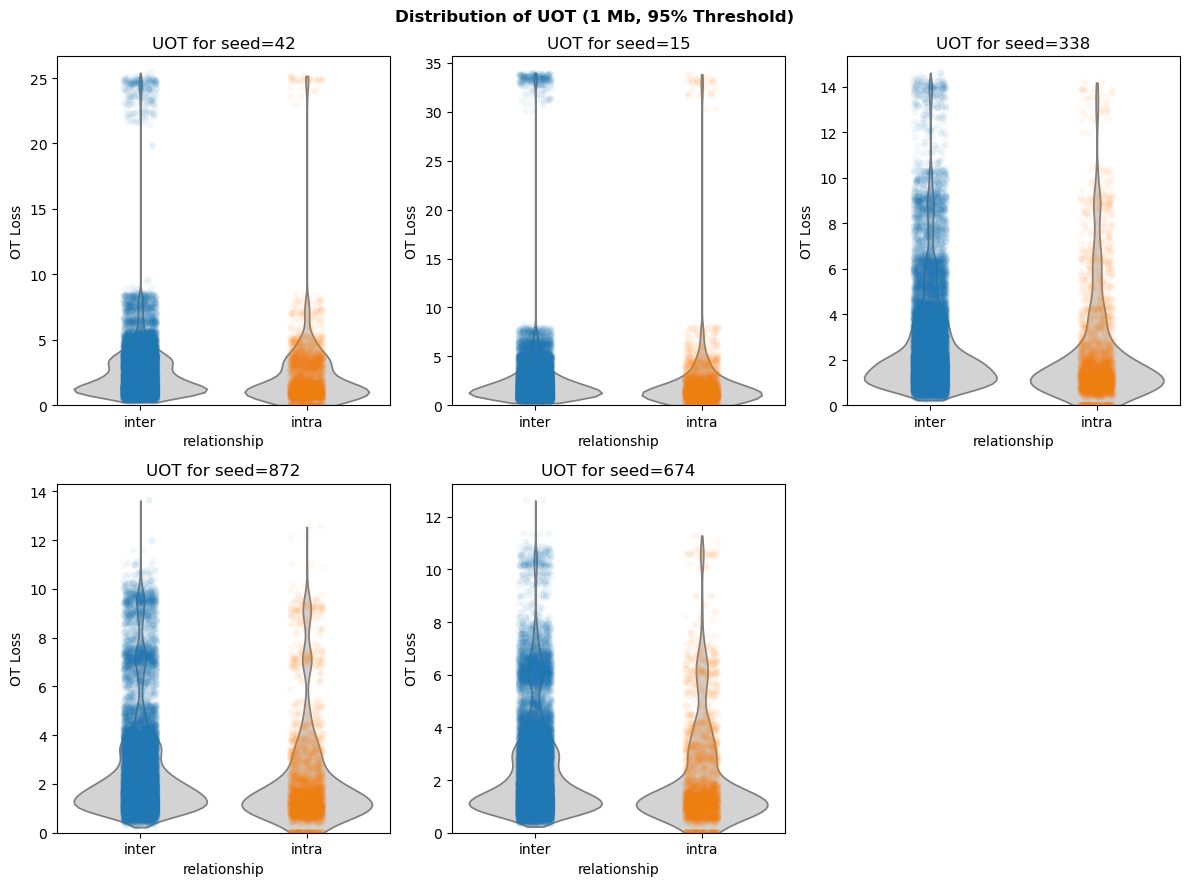

In [10]:
### Distributions, reg_m = 0.1 ###
    # Initializing figure
fig, ax = plt.subplots(2, 3, figsize=(12, 9))
axes = ax.flatten()

    # Adding subpanels
for i, (seed, data) in enumerate(reg_m01_data.items()):
    distribution_plot(data, axes[i], seed)

    # Adding titles
plt.suptitle("Distribution of UOT (1 Mb, 95% Threshold)", fontweight="bold")
fig.delaxes(ax[1, 2])
plt.tight_layout()

### Clustermaps

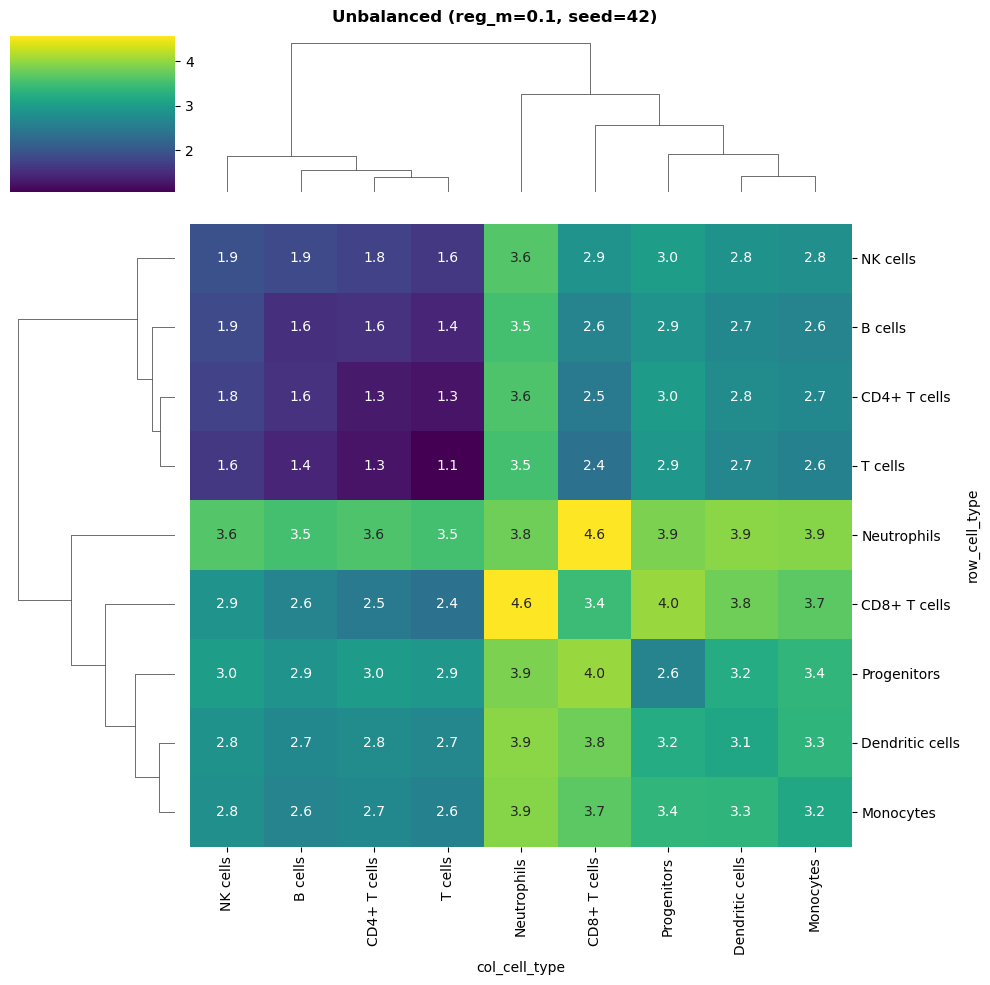

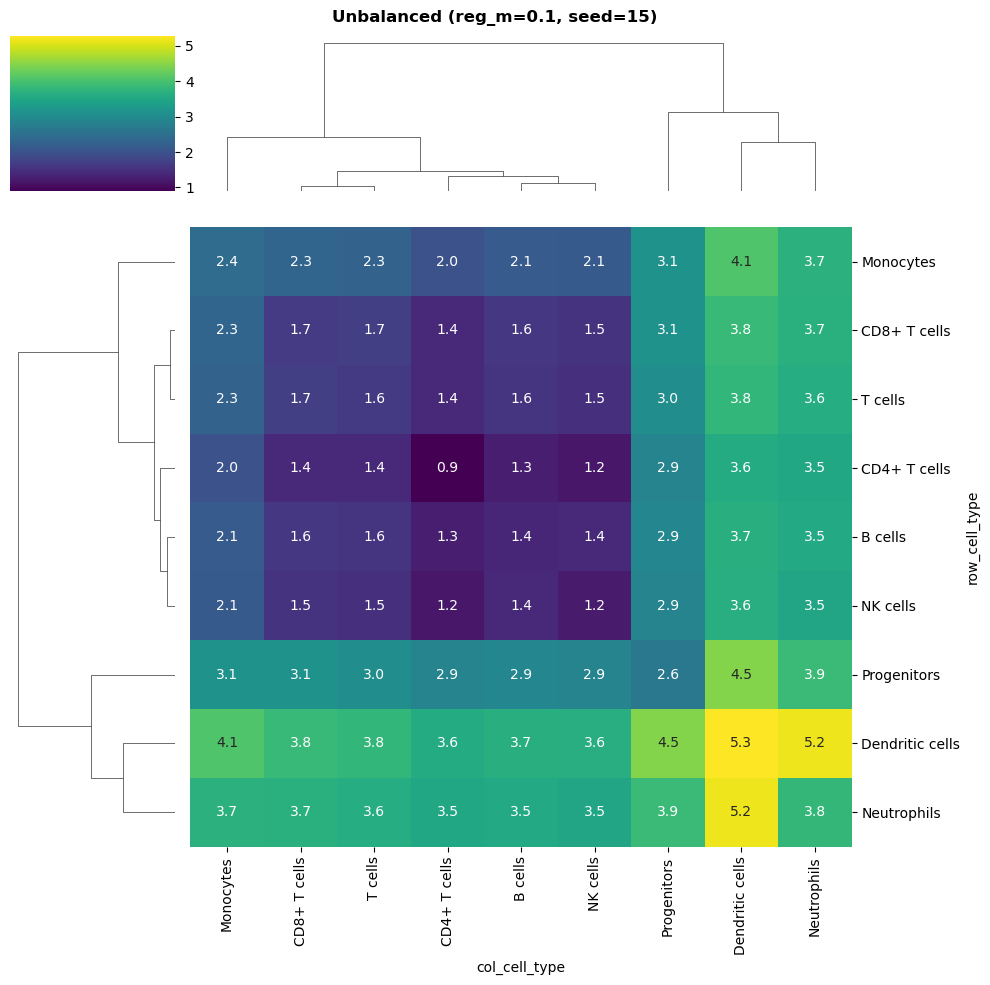

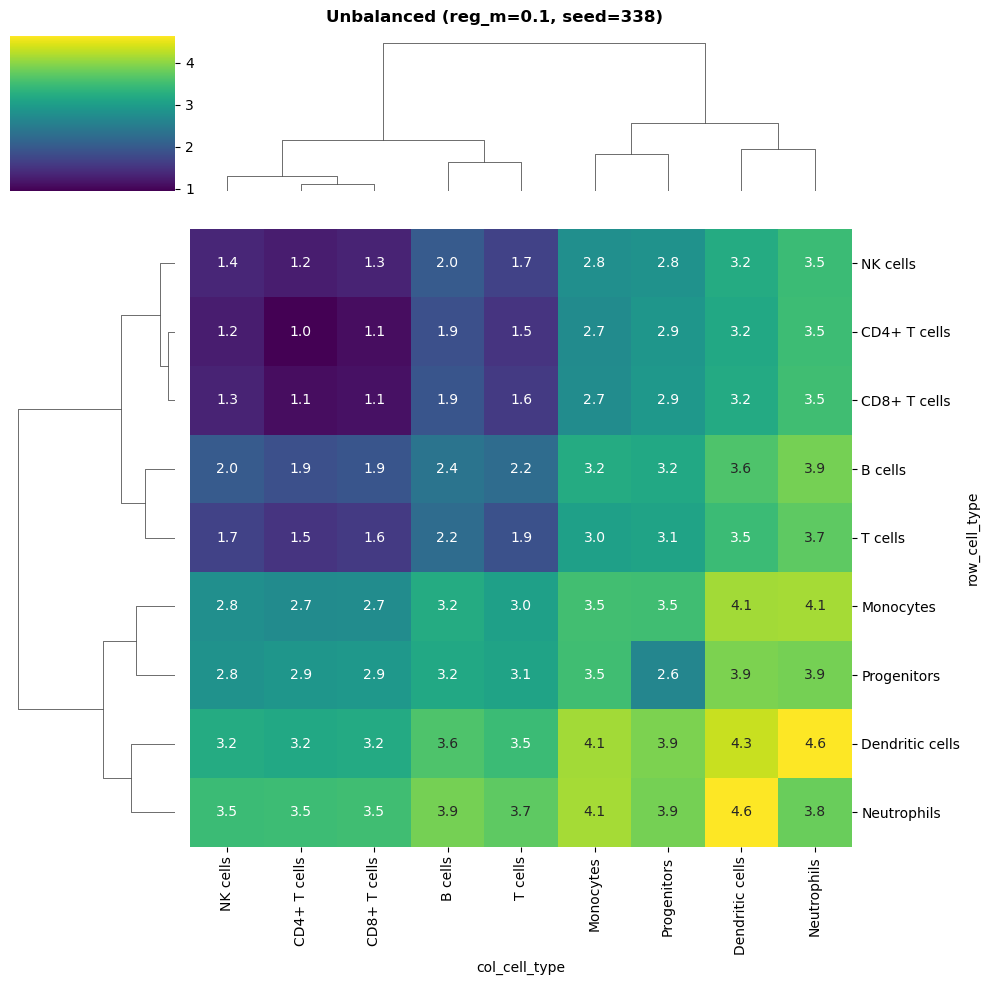

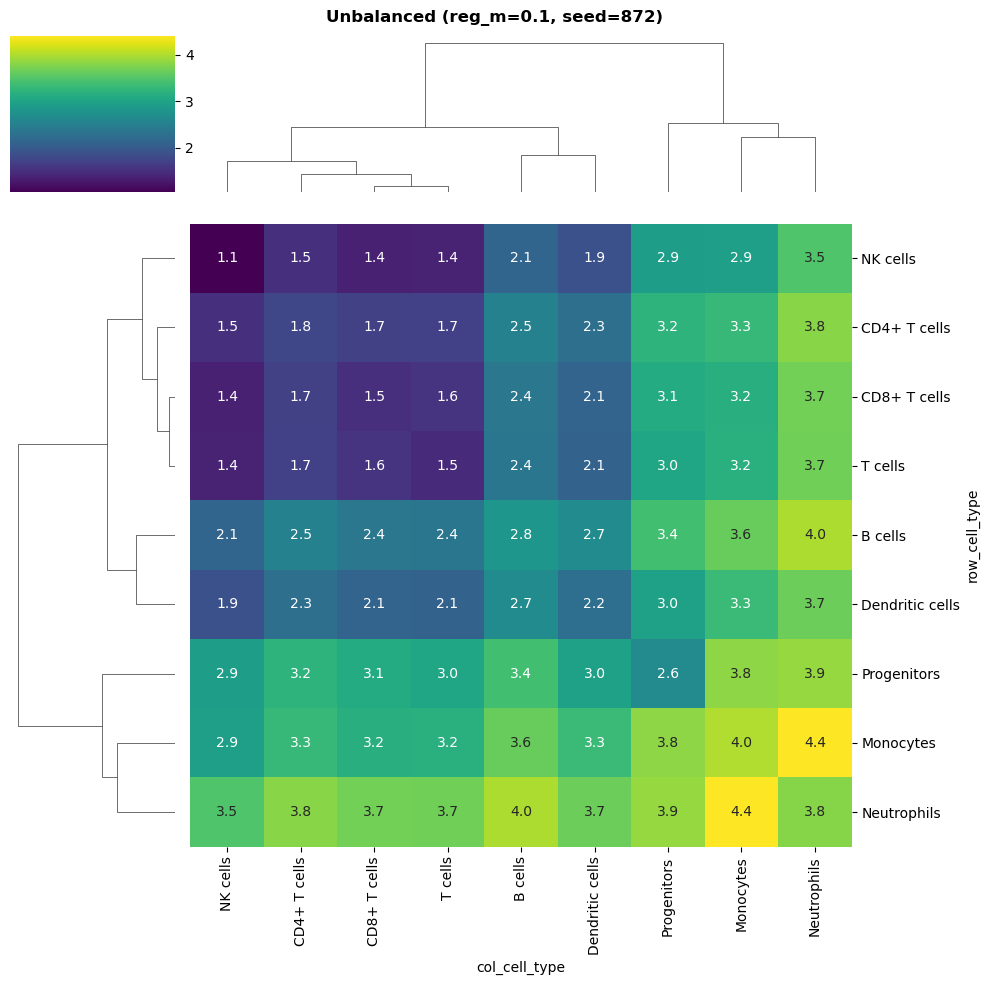

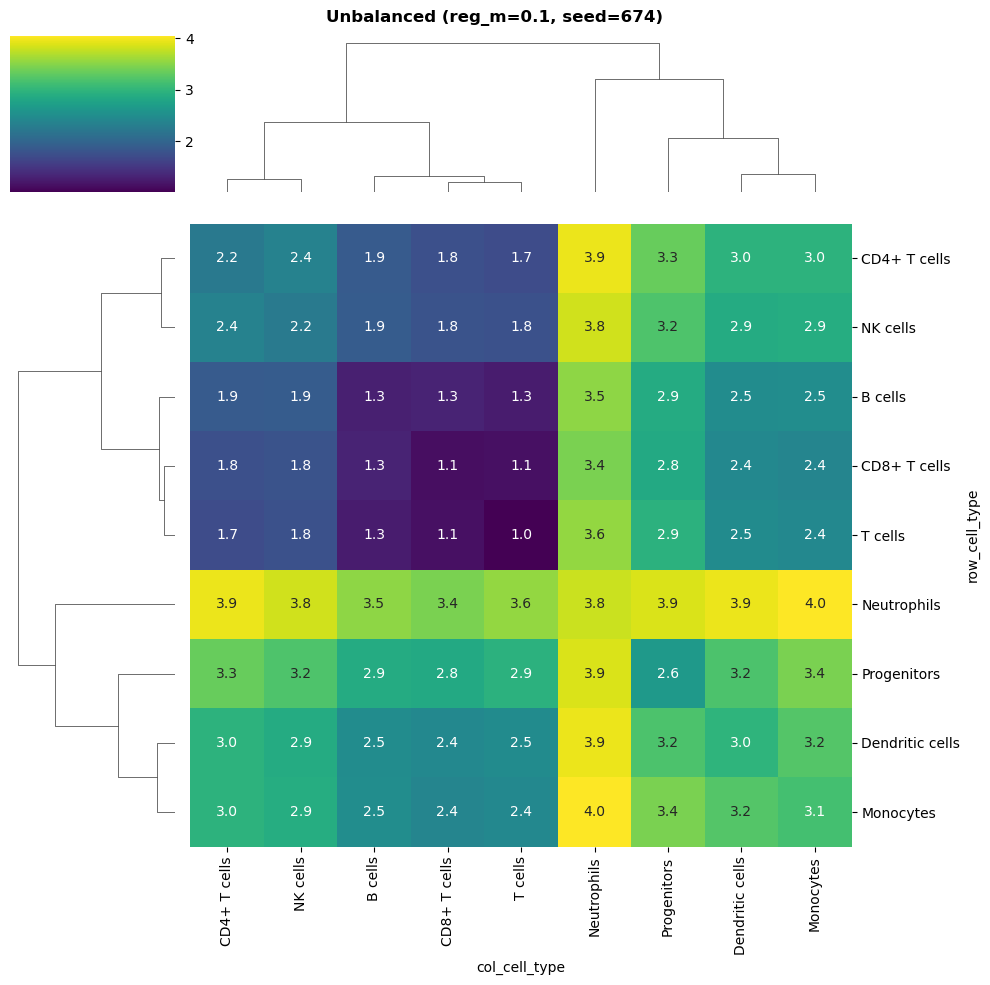

In [11]:
### Clustermaps, reg_m = 0.1 ###
for seed, data in reg_m01_data.items():
    generate_clustermap(data, 0.1, seed)

### Marginal Plots

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


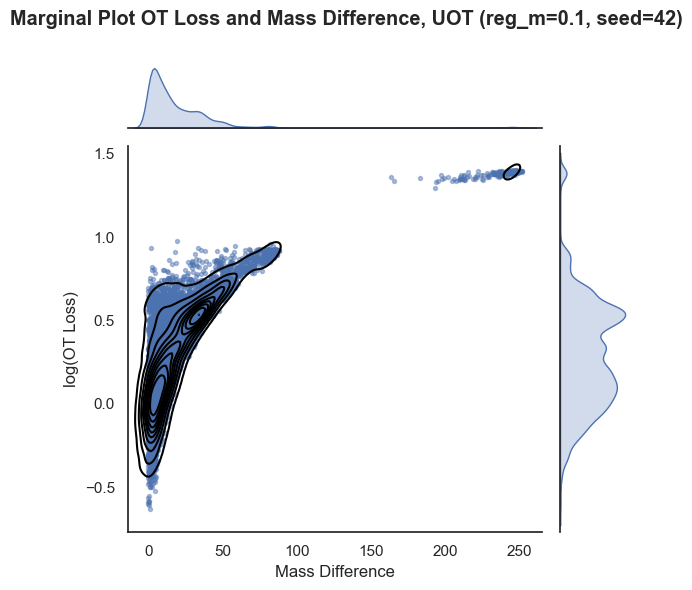

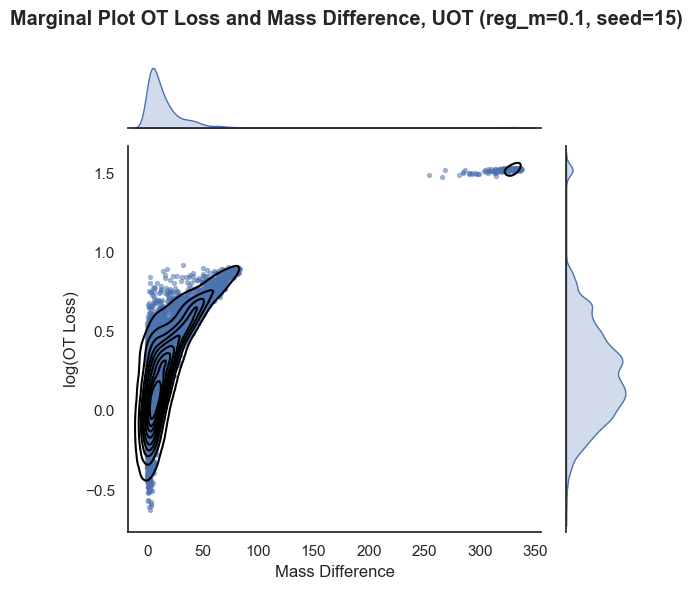

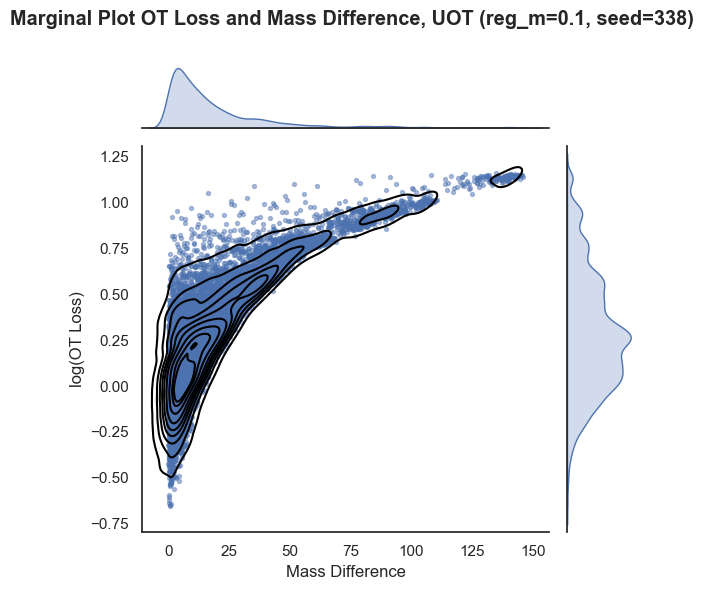

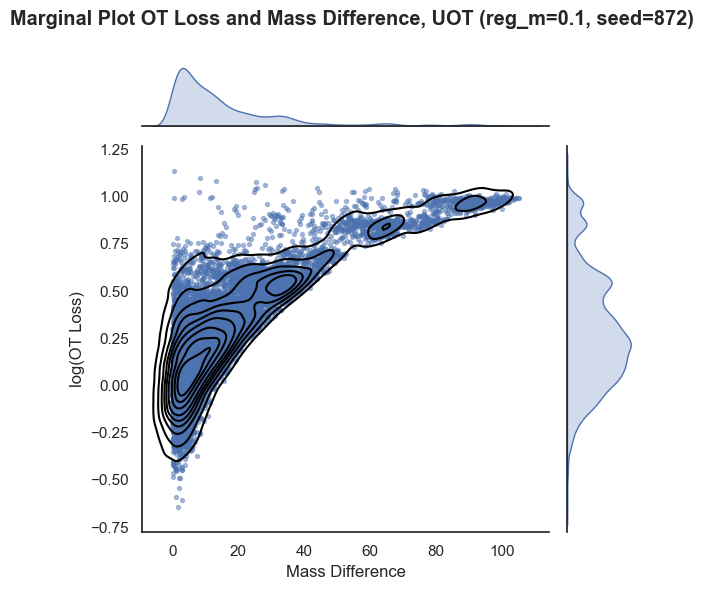

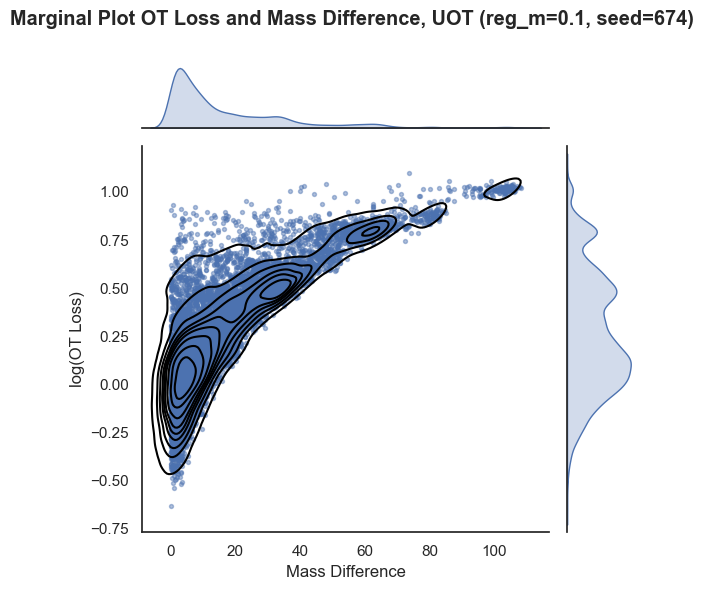

In [12]:
for seed, data in reg_m01_data.items():
    generate_marginal_plot(data, max_norm_mass, 0.1, seed)

## Pooling Data

### Concatinating

In [13]:
reg_m01_pooled = (
    pd.concat(reg_m01_data.values(), ignore_index=True)
    .drop_duplicates()
)
reg_m01_pooled

,row_file,col_file,value,row_cell_type,col_cell_type,relationship
0,arc_pair_221519,arc_pair_221519,0.000000,CD4+ T cells,CD4+ T cells,intra
1,arc_pair_161493,arc_pair_221519,1.310095,NK cells,CD4+ T cells,inter
2,arc_pair_48468,arc_pair_221519,5.405595,Neutrophils,CD4+ T cells,inter
3,arc_pair_684529,arc_pair_221519,1.008462,T cells,CD4+ T cells,inter
4,arc_pair_206257,arc_pair_221519,0.900312,CD4+ T cells,CD4+ T cells,intra
...,...,...,...,...,...,...
117038,arc_pair_291469,arc_pair_723396,2.130096,CD8+ T cells,Neutrophils,inter
117039,arc_pair_401573,arc_pair_723396,2.201328,CD4+ T cells,Neutrophils,inter
117040,arc_pair_703798,arc_pair_723396,4.475802,Dendritic cells,Neutrophils,inter
117041,arc_pair_77312,arc_pair_723396,2.821486,Dendritic cells,Neutrophils,inter


### Distribution plot

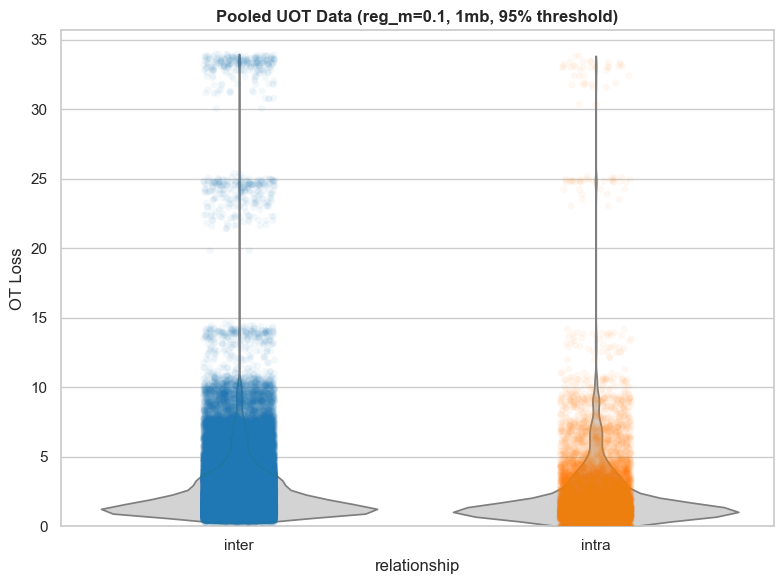

In [14]:
### Distribution plot ###
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Setting order
order = ["inter", "intra"]

# Stripplot
ax = sns.stripplot(
    data=reg_m01_pooled,
    x="relationship",
    y="value",
    order=order,
    hue="relationship",
    dodge=False,
    jitter=True,
    alpha=0.05,
    palette={
        "inter": "#1f77b4",
        "intra": "#ff7f0e"
    }
)

# Violin plot
sns.violinplot(
    data=reg_m01_pooled,
    x="relationship",
    y="value",
    order=order,
    inner=None,
    color="lightgray",
    cut=0,
)
ax.set_ybound(lower=0)

# Formatting
ax.set_ylabel("OT Loss")
ax.set_title("Pooled UOT Data (reg_m=0.1, 1mb, 95% threshold)", fontweight='bold')
plt.tight_layout()

### Clustermap

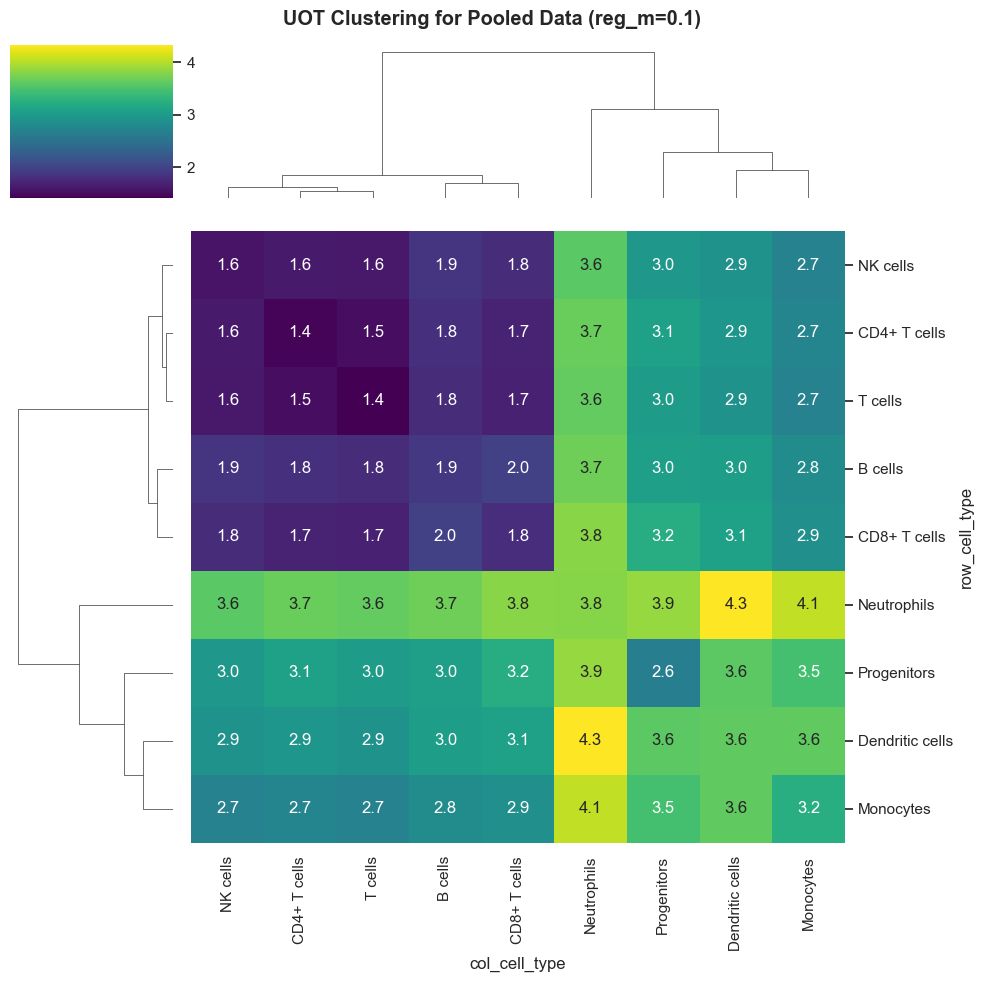

In [15]:
### Clustermap ###
# Calculating means per cell type
mean_matrix = reg_m01_pooled.groupby(
    ['row_cell_type', 'col_cell_type']
)["value"].mean()

# Prepping for generating heatmap
heatmap_data = mean_matrix.unstack()

# Clustermap
sns.clustermap(heatmap_data, annot=True, fmt='.1f', cmap='viridis')
plt.suptitle(f"UOT Clustering for Pooled Data (reg_m=0.1)", fontweight='bold')
plt.tight_layout()

### Marginal plot

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


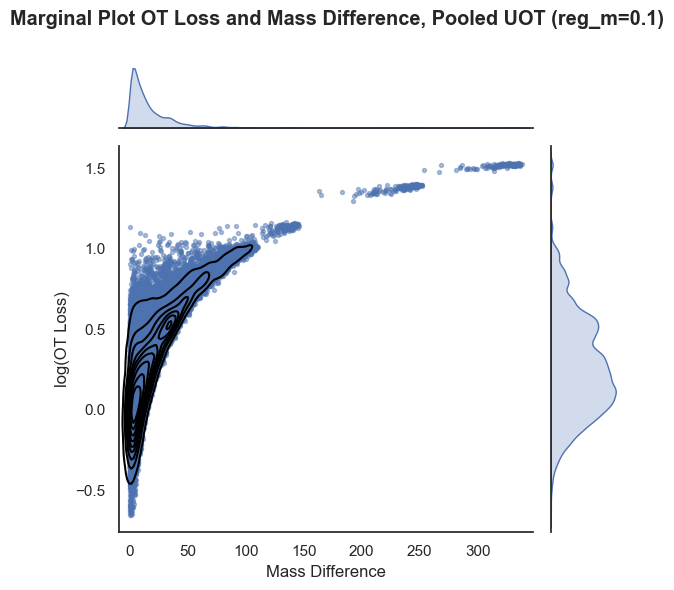

In [16]:
### Marginal plot, difference in mass ###
sns.set_theme(style="white")

# Adding mass data
long_df_mass = add_mass_to_long_df(reg_m01_pooled, max_norm_mass)

# Setting comparison
compare = 'mass_diff'
axis_title = 'Mass Difference'

# Initialize grid
g = sns.JointGrid(
    data=long_df_mass,
    x=compare,
    y='log_value',
    height=6
)

# Joint: light scatter + contour KDE
g.ax_joint.scatter(
    long_df_mass[compare],
    long_df_mass['log_value'],
    s=8,
    alpha=0.25
)

sns.kdeplot(
    data=long_df_mass,
    x=compare,
    y='log_value',
    ax=g.ax_joint,
    levels=10,
    bw_adjust=0.8,
    color='black'
)

# Marginals
sns.kdeplot(
    data=long_df_mass,
    x=compare,
    ax=g.ax_marg_x,
    fill=True,
    bw_adjust=0.8
)

sns.kdeplot(
    data=long_df_mass,
    y='log_value',
    ax=g.ax_marg_y,
    fill=True,
    bw_adjust=0.8
)

# Axis labels
g.set_axis_labels(axis_title, 'log(OT Loss)')

# Title
g.figure.suptitle(f'Marginal Plot OT Loss and {axis_title}, Pooled UOT (reg_m=0.1)', fontweight='bold')
g.figure.tight_layout(rect=[0, 0, 1, 0.98])

## Investigating outliers
The pooled data seems to include some severe outliers. Here, we'll remove them and visualize the results.

In [17]:
### Fetching outliers ###
reg_m01_pooled_outliers = reg_m01_pooled[reg_m01_pooled['value'] > 14]
outlier_file_counts = reg_m01_pooled_outliers['col_file'].value_counts()
outlier_file_names = outlier_file_counts[outlier_file_counts>20].index
outlier_file_names

Index(['arc_pair_665109', 'arc_pair_346988', 'arc_pair_23258'], dtype='object', name='col_file')

In [18]:
### Getting outlier cell type and mass ###
    # Import mass and celltype info
mass_ct_data = pd.read_csv(f'{metadata_save}/1mb_95_maxnorm_total_mass_celltypes.csv', index_col=0)

    # Fetching outlier info
mass_ct_data[mass_ct_data['cell_name'].isin(outlier_file_names)]

,cell_name,cell_type,total_mass
241,arc_pair_23258,B cells,151.567354
3707,arc_pair_346988,Dendritic cells,342.923305
7242,arc_pair_665109,CD8+ T cells,257.137210


In [19]:
### Trimming outliers from pooled data
reg_m01_pooled_trimmed = reg_m01_pooled[~reg_m01_pooled['row_file'].isin(outlier_file_names)]
reg_m01_pooled_trimmed = reg_m01_pooled_trimmed[~reg_m01_pooled_trimmed['col_file'].isin(outlier_file_names)]
reg_m01_pooled_trimmed

,row_file,col_file,value,row_cell_type,col_cell_type,relationship
0,arc_pair_221519,arc_pair_221519,0.000000,CD4+ T cells,CD4+ T cells,intra
1,arc_pair_161493,arc_pair_221519,1.310095,NK cells,CD4+ T cells,inter
2,arc_pair_48468,arc_pair_221519,5.405595,Neutrophils,CD4+ T cells,inter
3,arc_pair_684529,arc_pair_221519,1.008462,T cells,CD4+ T cells,inter
4,arc_pair_206257,arc_pair_221519,0.900312,CD4+ T cells,CD4+ T cells,intra
...,...,...,...,...,...,...
117038,arc_pair_291469,arc_pair_723396,2.130096,CD8+ T cells,Neutrophils,inter
117039,arc_pair_401573,arc_pair_723396,2.201328,CD4+ T cells,Neutrophils,inter
117040,arc_pair_703798,arc_pair_723396,4.475802,Dendritic cells,Neutrophils,inter
117041,arc_pair_77312,arc_pair_723396,2.821486,Dendritic cells,Neutrophils,inter


### Distribution plot

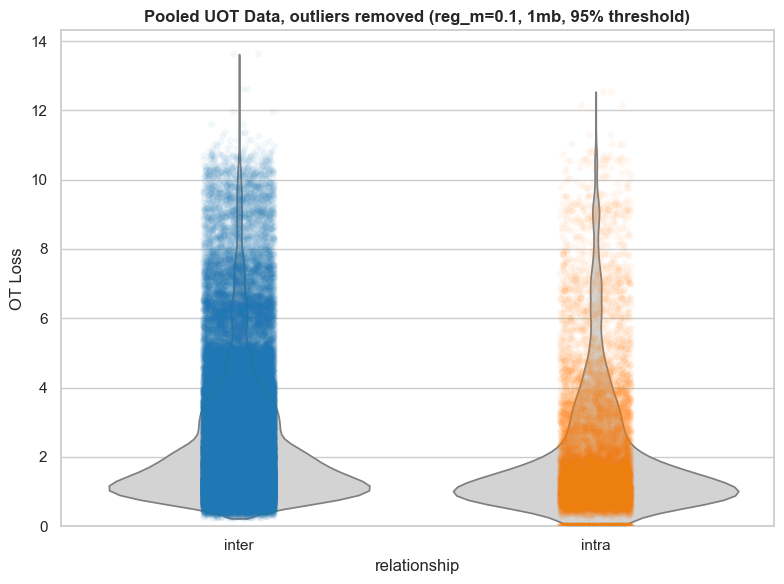

In [20]:
### Violin + swarm plot ###
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Setting order
order = ["inter", "intra"]

# Stripplot
ax = sns.stripplot(
    data=reg_m01_pooled_trimmed,
    x="relationship",
    y="value",
    order=order,
    hue="relationship",
    dodge=False,
    jitter=True,
    alpha=0.05,
    palette={
        "inter": "#1f77b4",
        "intra": "#ff7f0e"
    }
)

# Violin plot
sns.violinplot(
    data=reg_m01_pooled_trimmed,
    x="relationship",
    y="value",
    order=order,
    inner=None,
    color="lightgray",
    cut=0,
)
ax.set_ybound(lower=0)

# Formatting
ax.set_ylabel("OT Loss")
ax.set_title("Pooled UOT Data, outliers removed (reg_m=0.1, 1mb, 95% threshold)", fontweight='bold')
plt.tight_layout()

### Clustermap 

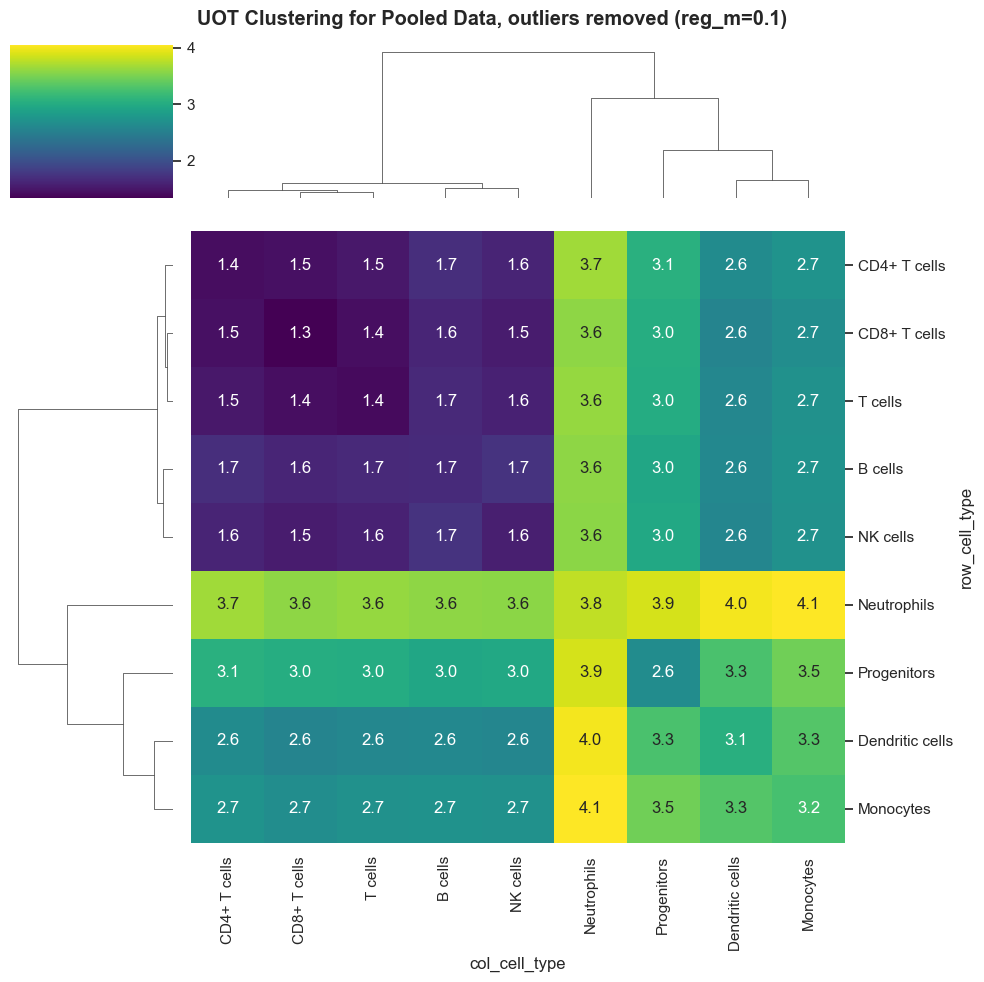

In [21]:
### Clustermap ###
# Calculating means per cell type
mean_matrix = reg_m01_pooled_trimmed.groupby(
    ['row_cell_type', 'col_cell_type']
)["value"].mean()

# Prepping for generating heatmap
heatmap_data = mean_matrix.unstack()

# Clustermap
sns.clustermap(heatmap_data, annot=True, fmt='.1f', cmap='viridis')
plt.suptitle(f"UOT Clustering for Pooled Data, outliers removed (reg_m=0.1)", fontweight='bold')
plt.tight_layout()

### Marginal plot

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


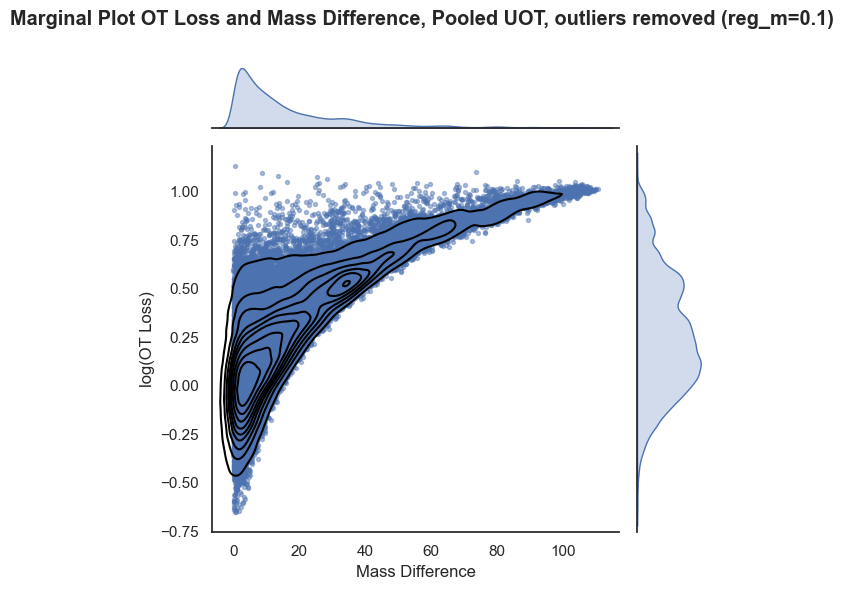

In [22]:
### Marginal plot, difference in mass ###
sns.set_theme(style="white")

# Adding mass data
long_df_mass = add_mass_to_long_df(reg_m01_pooled_trimmed, max_norm_mass)

# Setting comparison
compare = 'mass_diff'
axis_title = 'Mass Difference'

# Initialize grid
g = sns.JointGrid(
    data=long_df_mass,
    x=compare,
    y='log_value',
    height=6
)

# Joint: light scatter + contour KDE
g.ax_joint.scatter(
    long_df_mass[compare],
    long_df_mass['log_value'],
    s=8,
    alpha=0.25
)

sns.kdeplot(
    data=long_df_mass,
    x=compare,
    y='log_value',
    ax=g.ax_joint,
    levels=10,
    bw_adjust=0.8,
    color='black'
)

# Marginals
sns.kdeplot(
    data=long_df_mass,
    x=compare,
    ax=g.ax_marg_x,
    fill=True,
    bw_adjust=0.8
)

sns.kdeplot(
    data=long_df_mass,
    y='log_value',
    ax=g.ax_marg_y,
    fill=True,
    bw_adjust=0.8
)

# Axis labels
g.set_axis_labels(axis_title, 'log(OT Loss)')

# Title
g.figure.suptitle(f'Marginal Plot OT Loss and {axis_title}, Pooled UOT, outliers removed (reg_m=0.1)', fontweight='bold')
g.figure.tight_layout(rect=[0, 0, 1, 0.98])

## Removing neutrophils and progenitors
Neutrophils and progenitors are very underrepresented in the original data. Thus, their maps may not be particularly informative. Thus, we'll investigate clustering when these points are removed from the outlier removed data.

In [24]:
### Trimming neutrophils and progenitors ###
remove = ['Neutrophils', 'Progenitors']
reg_m01_pooled_cut = reg_m01_pooled_trimmed[~reg_m01_pooled_trimmed['row_cell_type'].isin(remove)]
reg_m01_pooled_cut = reg_m01_pooled_cut[~reg_m01_pooled_cut['col_cell_type'].isin(remove)]
reg_m01_pooled_cut

,row_file,col_file,value,row_cell_type,col_cell_type,relationship
0,arc_pair_221519,arc_pair_221519,0.000000,CD4+ T cells,CD4+ T cells,intra
1,arc_pair_161493,arc_pair_221519,1.310095,NK cells,CD4+ T cells,inter
3,arc_pair_684529,arc_pair_221519,1.008462,T cells,CD4+ T cells,inter
4,arc_pair_206257,arc_pair_221519,0.900312,CD4+ T cells,CD4+ T cells,intra
5,arc_pair_249616,arc_pair_221519,1.582474,Monocytes,CD4+ T cells,inter
...,...,...,...,...,...,...
116885,arc_pair_291469,arc_pair_27275,0.732050,CD8+ T cells,NK cells,inter
116886,arc_pair_401573,arc_pair_27275,1.046068,CD4+ T cells,NK cells,inter
116887,arc_pair_703798,arc_pair_27275,3.877761,Dendritic cells,NK cells,inter
116888,arc_pair_77312,arc_pair_27275,1.237062,Dendritic cells,NK cells,inter


### Distribution plot

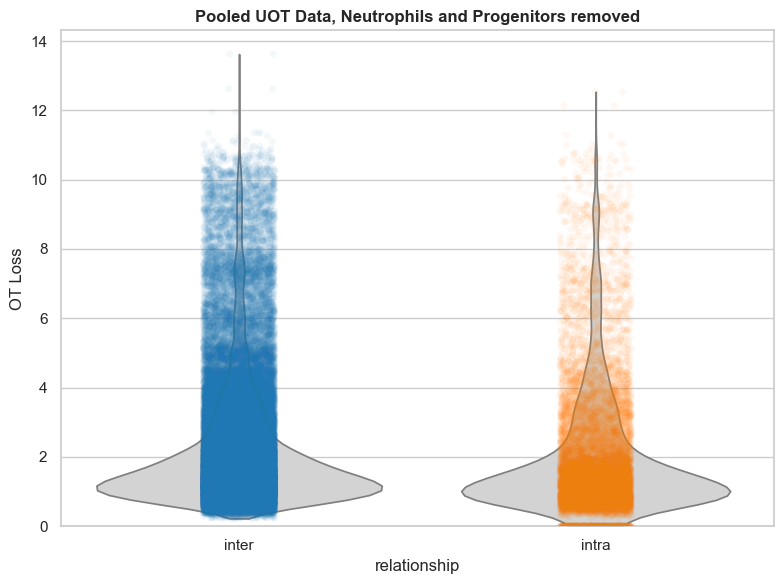

In [25]:
### Distribution plot ###
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Setting order
order = ["inter", "intra"]

# Stripplot
ax = sns.stripplot(
    data=reg_m01_pooled_cut,
    x="relationship",
    y="value",
    order=order,
    hue="relationship",
    dodge=False,
    jitter=True,
    alpha=0.05,
    palette={
        "inter": "#1f77b4",
        "intra": "#ff7f0e"
    }
)

# Violin plot
sns.violinplot(
    data=reg_m01_pooled_cut,
    x="relationship",
    y="value",
    order=order,
    inner=None,
    color="lightgray",
    cut=0,
)
ax.set_ybound(lower=0)

# Formatting
ax.set_ylabel("OT Loss")
ax.set_title("Pooled UOT Data, Neutrophils and Progenitors removed", fontweight='bold')
plt.tight_layout()

### Clustermap

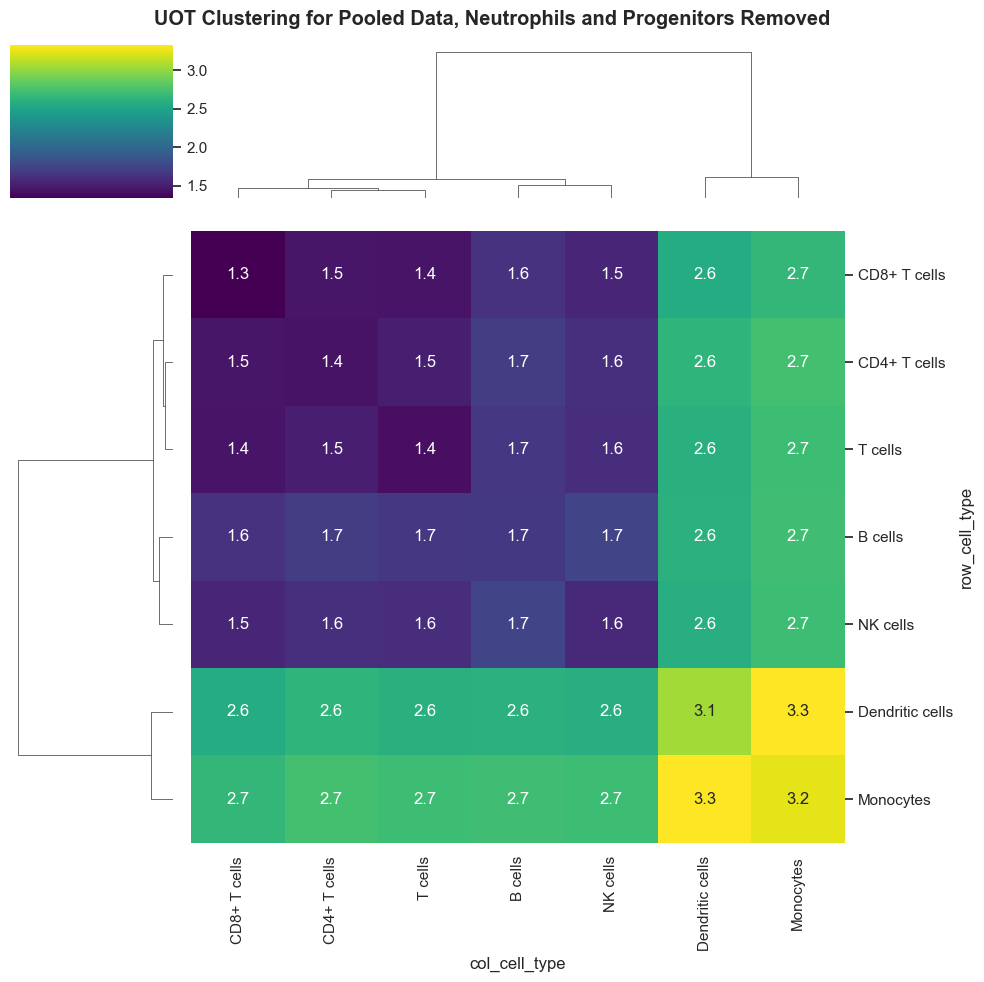

In [26]:
### Clustermap ###
# Calculating means per cell type
mean_matrix = reg_m01_pooled_cut.groupby(
    ['row_cell_type', 'col_cell_type']
)["value"].mean()

# Prepping for generating heatmap
heatmap_data = mean_matrix.unstack()

# Clustermap
sns.clustermap(heatmap_data, annot=True, fmt='.1f', cmap='viridis')
plt.suptitle(f"UOT Clustering for Pooled Data, Neutrophils and Progenitors Removed", fontweight='bold')
plt.tight_layout()

### Marginal plot

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


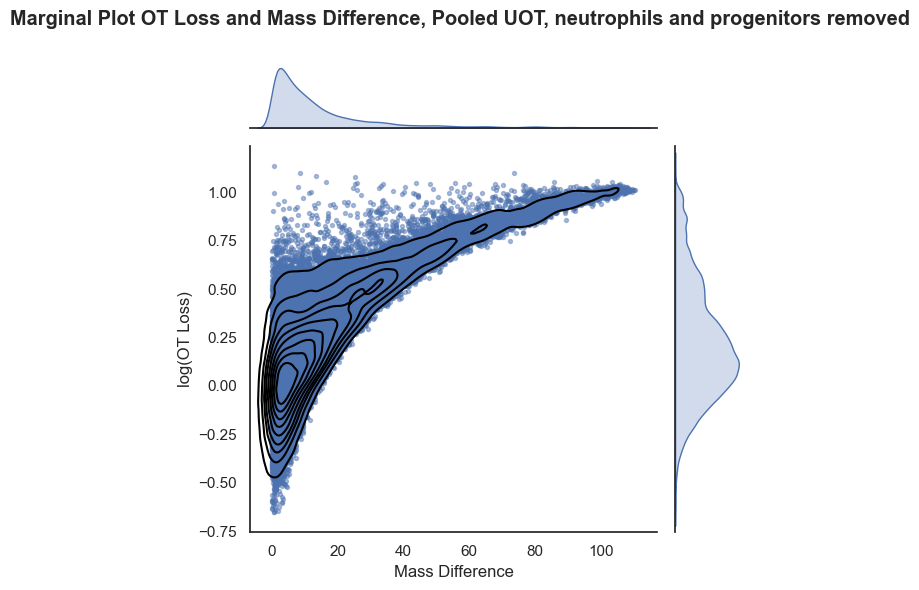

In [27]:
### Marginal plot, difference in mass ###
sns.set_theme(style="white")

# Adding mass data
long_df_mass = add_mass_to_long_df(reg_m01_pooled_cut, max_norm_mass)

# Setting comparison
compare = 'mass_diff'
axis_title = 'Mass Difference'

# Initialize grid
g = sns.JointGrid(
    data=long_df_mass,
    x=compare,
    y='log_value',
    height=6
)

# Joint: light scatter + contour KDE
g.ax_joint.scatter(
    long_df_mass[compare],
    long_df_mass['log_value'],
    s=8,
    alpha=0.25
)

sns.kdeplot(
    data=long_df_mass,
    x=compare,
    y='log_value',
    ax=g.ax_joint,
    levels=10,
    bw_adjust=0.8,
    color='black'
)

# Marginals
sns.kdeplot(
    data=long_df_mass,
    x=compare,
    ax=g.ax_marg_x,
    fill=True,
    bw_adjust=0.8
)

sns.kdeplot(
    data=long_df_mass,
    y='log_value',
    ax=g.ax_marg_y,
    fill=True,
    bw_adjust=0.8
)

# Axis labels
g.set_axis_labels(axis_title, 'log(OT Loss)')

# Title
g.figure.suptitle(f'Marginal Plot OT Loss and {axis_title}, Pooled UOT, neutrophils and progenitors removed', fontweight='bold')
g.figure.tight_layout(rect=[0, 0, 1, 0.98])